# Data Understanding and Preparation
Covers **Stage 1 + 2.1.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided (no change):* `config.py`. 
- *Provided to extend:* `src/data_prep.py` (function stubs). 
- *You build:* this notebook + the report.

Prereqs: `pip install -r requirements.txt`; extract the Kaggle casting dataset under `data/` (train/test → ok_front/def_front).

### 0. Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import config
from src import data_prep
# TODO: print config.CLASS_TO_IDX and config.POSITIVE_CLASS to confirm setup

print("Class mapping:", config.CLASS_TO_IDX)
print("Positive class:", config.POSITIVE_CLASS)
print("Positive class index:", config.POSITIVE_IDX)
print("Configured data directory:", config.DATA_DIR)

Class mapping: {'ok_front': 0, 'def_front': 1}
Positive class: def_front
Positive class index: 1
Configured data directory: C:\Users\naren\Documents\MLOps-Capstone\capstone\data


## **Stage 1.1 — Business & Data Understanding** <font color="red">[5 marks]</font>

- **1.1.1 — Business objective & justification [2]** — *to be done in the report*
- **1.1.2 — Success metric choice (recall/F1 on defects) [2]** — *to be done in the report*
- **1.1.3 — Dataset structure & class understanding [1]**

**Objective:** Understand the problem + dataset and name the right metric.

**Implement in:** this notebook (+ src/data_prep.find_data_root, list_images)

**Inputs → Outputs:** data/ images → counts + class distribution per split

**TODO:** locate the data root; count images per class per split; plot the distribution; state that defect = positive class and recall-on-defects (not accuracy) is the headline metric.

**Document here:** 1.1.1/1.1.2 in the report; 1.1.3 here (dataset structure).

In [5]:
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split
import pandas as pd
import matplotlib.pyplot as plt

root = data_prep.find_data_root()

records = []

for split in ("train", "test"):
    items = data_prep.list_images(root / split)

    for class_name, class_index in config.CLASS_TO_IDX.items():
        class_count = sum(
            label == class_index
            for _, label in items
        )

        records.append(
            {
                "split": split,
                "class_name": class_name,
                "class_index": class_index,
                "image_count": class_count,
            }
        )

class_distribution = pd.DataFrame(records)

print(f"Dataset root: {root}")
print(f"Total images: {class_distribution['image_count'].sum()}")
display(class_distribution)

Matplotlib is building the font cache; this may take a moment.


Dataset root: C:\Users\naren\Downloads\casting_data
Total images: 160


,split,class_name,class_index,image_count
0,train,ok_front,0,40
1,train,def_front,1,40
2,test,ok_front,0,40
3,test,def_front,1,40


In [ ]:
#Create and display distribution table for each split and class
distribution_table = (
    class_distribution
    .pivot(
        index="split",
        columns="class_name",
        values="image_count",
    )
    .reindex(columns=config.CLASSES)
    .fillna(0)
    .astype(int)
)

distribution_table["total"] = distribution_table.sum(axis=1)

display(distribution_table)

class_name,ok_front,def_front,total
split,,,
test,40,40,80
train,40,40,80


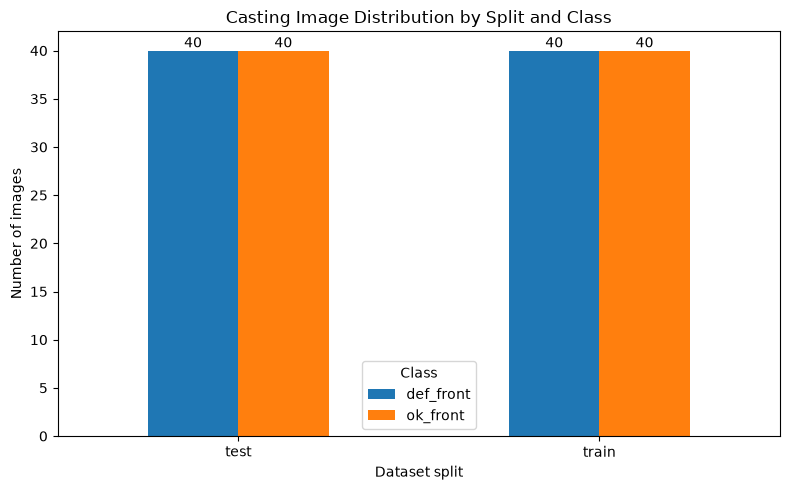

In [ ]:
#plot the distribution of images by split and class
plot_data = class_distribution.pivot(
    index="split",
    columns="class_name",
    values="image_count",
)

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Casting Image Distribution by Split and Class")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Class")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains two classes:

- `ok_front`, mapped to class label 0, represents acceptable castings.
- `def_front`, mapped to class label 1, represents defective castings.

The defective class is deliberately treated as the positive class because the
main operational objective is to detect defective castings before they continue
through production.

The current development dataset contains 160 images. The supplied training
directory contains 80 images and the supplied test directory contains 80 images.
Each split contains 40 acceptable and 40 defective images, resulting in an even
50:50 class distribution.

The balanced distribution means that class imbalance is not present in this
development subset. However, accuracy will still not be used as the primary
selection metric because a false negative represents a defective casting that
the model incorrectly accepts. Recall on the defect class therefore remains the
headline metric.

The current dataset is a small development subset rather than the approximately
7,348-image dataset described in the project specification. The implementation
is therefore designed to work without changes when the complete dataset is used.

## **Stage 1.2 — Data Quality Validation** <font color="red">[5 marks]</font>

- **1.2.1 — Corrupt-file & image-dimension checks [2]**
- **1.2.2 — Duplicate detection (hashing) — leakage guard [2]**
- **1.2.3 — Class distribution + pass/fail report [1]**

**Objective:** Programmatically validate image quality before any split.

**Implement in:** src/data_prep.validate_quality

**Inputs → Outputs:** data root → a pass/fail report dict (corrupt, duplicates, dimensions, distribution)

**TODO:** check missing/corrupt files (Image.verify) and dimensions (1.2.1); detect DUPLICATE images via md5/hash (1.2.2); quantify class balance + print a pass/fail report (1.2.3); expect ~7,348 images, ~64 duplicates.

**Document here:** the quality report + why duplicate detection prevents train/test leakage.

In [9]:
# TODO 1.2.1-1.2.3: qc = data_prep.validate_quality(root); print(qc['total_images'], qc['passed'])
import json

root = data_prep.find_data_root()
quality_report = data_prep.validate_quality(root)

quality_report_path = (
    config.ARTIFACT_DIR / "data_quality_report.json"
)

quality_report_path.write_text(
    json.dumps(quality_report, indent=2),
    encoding="utf-8",
)

print(f"Quality report saved to: {quality_report_path}")
print(f"Overall quality status: "
      f"{'PASS' if quality_report['passed'] else 'FAIL'}")

Quality report saved to: C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\data_quality_report.json
Overall quality status: FAIL


In [ ]:
# Display the result of corrupt files and invalid dimensions in a tabular format using pandas DataFrame. If there are no corrupt files or invalid dimensions, print a PASS message.
if quality_report["corrupt_files"]:
    display(pd.DataFrame(quality_report["corrupt_files"]))
else:
    print("PASS: No corrupt or unreadable image files were detected.")

if quality_report["invalid_dimensions"]:
    display(pd.DataFrame(quality_report["invalid_dimensions"]))
else:
    print("PASS: All readable images have dimensions 300 x 300 pixels.")

PASS: No corrupt or unreadable image files were detected.
PASS: All readable images have dimensions 300 x 300 pixels.


In [ ]:
# Display the result of duplicate images in a tabular format using pandas DataFrame.
duplicate_summary = {
    "duplicate_group_count":
        quality_report["duplicates"]["duplicate_group_count"],
    "duplicate_file_count":
        quality_report["duplicates"]["duplicate_file_count"],
    "excess_duplicate_count":
        quality_report["duplicates"]["excess_duplicate_count"],
    "cross_split_group_count":
        quality_report["duplicates"]["cross_split_group_count"],
    "cross_class_group_count":
        quality_report["duplicates"]["cross_class_group_count"],
}

display(pd.DataFrame([duplicate_summary]))

,duplicate_group_count,duplicate_file_count,excess_duplicate_count,cross_split_group_count,cross_class_group_count
0,22,44,22,22,0


In [19]:
# Display the details of duplicate images in a tabular format using pandas DataFrame.
duplicate_rows = []

for group in quality_report["duplicates"]["groups"]:
    duplicate_rows.append(
        {
            "hash": group["md5"][:12],
            "file_count": group["file_count"],
            "cross_split": group["cross_split"],
            "cross_class": group["cross_class"],
            "files": " | ".join(group["files"]),
        }
    )

duplicate_examples = pd.DataFrame(duplicate_rows)

if duplicate_examples.empty:
    print("No exact duplicate images were detected.")
else:
    display(duplicate_examples.head(10))

,hash,file_count,cross_split,cross_class,files
0,033f2c3cd5e4,2,True,False,test/ok_front/cast_ok_0_1022.jpeg | train/ok_f...
1,05d1192be741,2,True,False,test/ok_front/cast_ok_0_1095.jpeg | train/ok_f...
2,0ef55c5885f5,2,True,False,test/ok_front/cast_ok_0_1003.jpeg | train/ok_f...
3,22ec0f424b08,2,True,False,test/ok_front/cast_ok_0_1066.jpeg | train/ok_f...
4,329e01de9631,2,True,False,test/ok_front/cast_ok_0_1096.jpeg | train/ok_f...
5,33a0b23b1e90,2,True,False,test/ok_front/cast_ok_0_1069.jpeg | train/ok_f...
6,355f9117005a,2,True,False,test/ok_front/cast_ok_0_1040.jpeg | train/ok_f...
7,37b99d4b316e,2,True,False,test/ok_front/cast_ok_0_1077.jpeg | train/ok_f...
8,3b20a1bcf173,2,True,False,test/ok_front/cast_ok_0_1028.jpeg | train/ok_f...
9,4d0e3e62ae89,2,True,False,test/ok_front/cast_ok_0_1019.jpeg | train/ok_f...


In [ ]:
# Display the class distribution for each split in a tabular format using pandas DataFrame.
class_rows = []

for split, class_results in (
    quality_report["class_distribution"].items()
):
    for class_name, result in class_results.items():
        class_rows.append(
            {
                "split": split,
                "class_name": class_name,
                "class_index":
                    config.CLASS_TO_IDX[class_name],
                "count": result["count"],
                "percentage": result["percentage"],
            }
        )

quality_class_distribution = pd.DataFrame(class_rows)

display(quality_class_distribution)

,split,class_name,class_index,count,percentage
0,train,ok_front,0,40,50.0
1,train,def_front,1,40,50.0
2,test,ok_front,0,40,50.0
3,test,def_front,1,40,50.0


In [ ]:
# Display the results of quality checks in a tabular format using pandas DataFrame.
quality_check_table = pd.DataFrame(
    [
        {
            "check": check_name,
            "status": result["status"],
            "issue_count": result["issue_count"],
        }
        for check_name, result
        in quality_report["checks"].items()
    ]
)

display(quality_check_table)

,check,status,issue_count
0,required_directories,PASS,0
1,corrupt_files,PASS,0
2,image_dimensions,PASS,0
3,class_distribution,PASS,0
4,exact_duplicates,FAIL,22
5,cross_split_leakage,FAIL,22
6,class_label_consistency,PASS,0


### Data-quality interpretation

A programmatic data-quality assessment was completed before creating the final
model-development partitions. The validation covered directory structure,
class presence, image readability, expected image dimensions, exact duplicate
detection and cross-split leakage.

The dataset contains 160 images, with 40 acceptable and 40 defective images in
each of the supplied train and test directories. No corrupt or unreadable files
were detected, and all images have the expected dimensions of 300 × 300 pixels.

Exact-content hashing identified 22 duplicate groups. All 22 duplicate groups
cross the supplied train/test boundary. This represents data leakage because
identical visual information could be available during both model training and
final evaluation. Performance calculated using the original supplied split
could therefore overestimate the model's ability to generalise to unseen
castings.

No duplicate groups crossed class boundaries, indicating that identical images
were not assigned conflicting labels.

The overall data-quality result is FAIL because the supplied train/test
structure is not leakage-safe. The original partitions will not be used
unchanged. During dataset versioning, duplicate images will be grouped by their
content hash so that identical image content cannot appear in more than one
final partition.

## **Stage 1.3 — Dataset Versioning & Metadata** <font color="red">[5 marks]</font>

- **1.3.1 — Reproducible, stratified train/val/test split [3]**
- **1.3.2 — Split snapshot + metadata.json (versioning) [2]**

**Objective:** Create reproducible, versioned splits.

**Implement in:** src/data_prep.build_splits

**Inputs → Outputs:** data root + version id → train/val/test file lists + metadata.json

**TODO:** make a STRATIFIED train/val/test split (seed 42) (1.3.1); snapshot the file lists + write metadata.json (version id, date, class defs, split sizes, seed) (1.3.2).

**Document here:** the split sizes + the metadata record.

In [ ]:
# TODO 1.3.1-1.3.2: meta = data_prep.build_splits(root, 'v1'); print(meta['split_info'])
#Build the dataset splits using the specified version identifier and print the metadata information, including version ID, random seed, 
# split policy, and leakage check status.
meta = data_prep.build_splits(root, "v1")

print(f"Dataset version: {meta['version_id']}")
print(f"Random seed: {meta['random_seed']}")
print(f"Split policy: {meta['split_policy']}")
print(
    "Leakage-safe:",
    meta["leakage_check"]["passed"],
)

Dataset version: v1
Random seed: 42
Split policy: prefer_train_remove_test_hash_overlap_v1
Leakage-safe: True


In [ ]:
# Display the split information, including the size of each split and the class counts and percentages for each class 
split_rows = []

for split_name, split_result in meta["split_info"].items():
    split_rows.append(
        {
            "split": split_name,
            "total": split_result["size"],
            "ok_front": split_result[
                "class_counts"
            ]["ok_front"],
            "def_front": split_result[
                "class_counts"
            ]["def_front"],
            "ok_percentage": split_result[
                "class_percentages"
            ]["ok_front"],
            "defect_percentage": split_result[
                "class_percentages"
            ]["def_front"],
        }
    )

split_summary_df = pd.DataFrame(split_rows)

display(split_summary_df)

,split,total,ok_front,def_front,ok_percentage,defect_percentage
0,train,68,34,34,50.00,50.00
1,val,12,6,6,50.00,50.00
2,test,58,18,40,31.03,68.97


In [ ]:
#Display the results of duplicate handling and remediation.
duplicate_metadata = meta["duplicate_handling"]

duplicate_remediation_df = pd.DataFrame(
    [
        {
            "measure": "Cross-split duplicate groups detected",
            "value": duplicate_metadata[
                "cross_split_duplicate_group_count"
            ],
        },
        {
            "measure": "Test files excluded due to train overlap",
            "value": duplicate_metadata[
                "cross_split_test_files_excluded"
            ],
        },
        {
            "measure": "Within-train duplicates removed",
            "value": duplicate_metadata[
                "within_train_duplicates_removed"
            ],
        },
        {
            "measure": "Within-test duplicates removed",
            "value": duplicate_metadata[
                "within_test_duplicates_removed"
            ],
        },
    ]
)

display(duplicate_remediation_df)

,measure,value
0,Cross-split duplicate groups detected,22
1,Test files excluded due to train overlap,22
2,Within-train duplicates removed,0
3,Within-test duplicates removed,0


In [ ]:
#Display the results of leakage checks.
display(
    pd.DataFrame(
        [
            {
                "comparison": name,
                "overlapping_hashes": count,
            }
            for name, count
            in meta["leakage_check"].items()
            if name != "passed"
        ]
    )
)

assert meta["leakage_check"]["passed"]

,comparison,overlapping_hashes
0,train_val,0
1,train_test,0
2,val_test,0


In [26]:
#Display the manifest evidence in a tabular format
# Dataset version created by build_splits()
DATASET_VERSION = "v1"

metadata_path = (
    config.SPLIT_DIR
    / DATASET_VERSION
    / "metadata.json"
)

if not metadata_path.exists():
    raise FileNotFoundError(
        f"Metadata file was not found: {metadata_path}. "
        "Run data_prep.build_splits() first."
    )

with metadata_path.open("r", encoding="utf-8") as file:
    metadata = json.load(file)

print(f"Metadata loaded from: {metadata_path}")

metadata_summary = pd.DataFrame(
    [
        {
            "dataset_version": metadata["version_id"],
            "created_at_utc": metadata["created_at_utc"],
            "random_seed": metadata["random_seed"],
            "validation_fraction": metadata["validation_fraction"],
            "positive_class": metadata["positive_class"],
            "positive_class_index": metadata[
                "positive_class_index"
            ],
            "split_policy": metadata["split_policy"],
            "source_inventory_sha256": metadata[
                "source_inventory_sha256"
            ],
        }
    ]
)

display(metadata_summary)

Metadata loaded from: C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\splits\v1\metadata.json


,dataset_version,created_at_utc,random_seed,validation_fraction,positive_class,positive_class_index,split_policy,source_inventory_sha256
0,v1,2026-08-04T10:31:24.843884+00:00,42,0.15,def_front,1,prefer_train_remove_test_hash_overlap_v1,a504579a5a8e84c39a0f563112496693f1d077a42d3964...


In [ ]:
#Display the manifest evidence in a tabular format using pandas DataFrame.
version_dir = config.SPLIT_DIR / meta["version_id"]

manifest_evidence = pd.DataFrame(
    [
        {
            "artefact": file_name,
            "path": str(version_dir / file_name),
            "sha256": meta["manifest_sha256"][split_name],
        }
        for split_name, file_name
        in meta["manifest_files"].items()
    ]
)

display(manifest_evidence)

,artefact,path,sha256
0,train.json,C:\Users\naren\Documents\MLOps-Capstone\capsto...,73fc01713edd9b14452ffe3048ce1dd494ace1a051516b...
1,val.json,C:\Users\naren\Documents\MLOps-Capstone\capsto...,1c7a749d452d142e390d5babc313bc1fd027537434e6a5...
2,test.json,C:\Users\naren\Documents\MLOps-Capstone\capsto...,3b95b2877d52e70839d86111258cb8aa75faa1b13411c5...


In [ ]:
# Verify that re-running the build_splits function with the same version identifier returns the same immutable manifests and metadata.
manifest_before = {
    name: (
        version_dir / f"{name}.json"
    ).read_text(encoding="utf-8")
    for name in ("train", "val", "test")
}

meta_repeated = data_prep.build_splits(root, "v1")

manifest_after = {
    name: (
        version_dir / f"{name}.json"
    ).read_text(encoding="utf-8")
    for name in ("train", "val", "test")
}

assert manifest_before == manifest_after
assert meta_repeated == meta

print(
    "PASS: Re-running build_splits with version v1 "
    "returned the same immutable manifests."
)

PASS: Re-running build_splits with version v1 returned the same immutable manifests.


### Dataset versioning interpretation

Dataset version `v1` was created using random seed 42. The supplied
training folder was used as the source of the training and validation
partitions, while the supplied test folder remained the source of the final
test partition.

The original dataset contained 22 exact-image groups that crossed the
train/test boundary. To remove this leakage, the training copy was retained
and matching test copies were excluded. Exact duplicates were identified
using image-content hashes rather than file names.

The cleaned training data was divided into training and validation sets using
a class-stratified 85:15 split. This preserved equal representation of
acceptable and defective castings in both model-development partitions.

The final train, validation and test manifests contain relative image paths
and fixed labels. They are stored under `artifacts/splits/v1` together with a
`metadata.json` record containing the dataset version, creation timestamp,
random seed, class definitions, split sizes, duplicate-remediation policy,
dataset fingerprint and manifest hashes.

The final leakage check reported zero overlapping image hashes between
train, validation and test. Re-running the split function with the same source
inventory and version returned the existing immutable snapshot, confirming
reproducibility.

## **Stage 1.4 — EDA & Methodology Design** <font color="red">[5 marks]</font>

- **1.4.1 — Image-characteristic EDA [3]** — *to be done in this notebook and the report*
- **1.4.2 — End-to-end MLOps workflow design [2]** — *to be done in the report*

**Objective:** Explore image characteristics that motivate preprocessing + drift features.

**Implement in:** this notebook (+ src/data_prep.image_features)

**Inputs → Outputs:** sample images → a feature table (brightness/contrast/edge/sharpness/dark-ratio) by class

**TODO:** show a sample grid (OK vs Defective) + per-class feature means (1.4.1); in the report, design the end-to-end MLOps workflow (1.4.2).

**Document here:** an interpretation cell (1.4.1) + the workflow design in the report (1.4.2).

In [27]:
# TODO 1.4.1: sample-image grid; per-class image_features means
#Load the training split of the dataset using the specified version identifier and root directory,
# and print the number of images in the training split.
DATASET_VERSION = "v1"

eda_items = data_prep.load_split(
    DATASET_VERSION,
    "train",
    root,
)

print("Dataset version:", DATASET_VERSION)
print("EDA split: train")
print("Number of images:", len(eda_items))

Dataset version: v1
EDA split: train
Number of images: 68


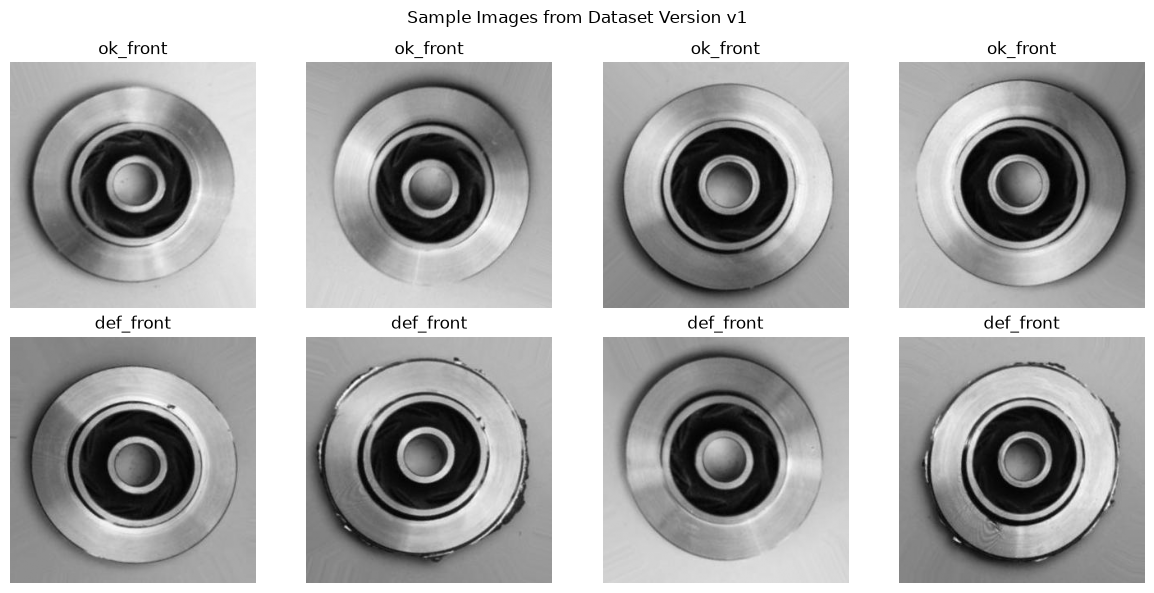

In [ ]:
# sample-image grid; per-class image_features means
from PIL import Image
import random

random.seed(config.RANDOM_SEED)

samples_per_class = 4

#Create a grid of sample images from the training split, with one row per class and a specified number of samples per class. 
# Each image is displayed in grayscale, and the title of each subplot indicates the class name.
fig, axes = plt.subplots(
    2,
    samples_per_class,
    figsize=(12, 6),
)

#for each class in the dataset, randomly select a specified number of sample images from the training split and display them in a grid format.
for row, class_name in enumerate(config.CLASSES):
    class_index = config.CLASS_TO_IDX[class_name]

    class_items = [
        path
        for path, label in eda_items
        if label == class_index
    ]

    #select a random sample of images for the current class, ensuring that the number of samples does not exceed the available images for that class.
    selected_images = random.sample(
        class_items,
        k=min(samples_per_class, len(class_items)),
    )

    #Display the selected sample images for the current class in the corresponding row of the grid, converting each image 
    # to grayscale and setting the title of each subplot to the class name.
    for column, image_path in enumerate(selected_images):
        with Image.open(image_path) as image:
            axes[row, column].imshow(
                image.convert("L"),
                cmap="gray",
            )

        axes[row, column].set_title(class_name)
        axes[row, column].axis("off")

plt.suptitle("Sample Images from Dataset Version v1")
plt.tight_layout()
plt.show()

In [ ]:
#Create a DataFrame containing the extracted features for each image in the dataset.
feature_rows = []

for image_path, label in eda_items:
    with Image.open(image_path) as image:
        features = data_prep.image_features(image)

    feature_rows.append(
        {
            "class_name": config.IDX_TO_CLASS[label],
            **features,
        }
    )

eda_features = pd.DataFrame(feature_rows)

display(eda_features.head())

,class_name,brightness,contrast,edge_density,sharpness,mean_intensity
0,def_front,0.584188,61.781536,0.109789,718.930847,135.552582
1,def_front,0.592446,57.359444,0.098844,660.537903,139.761139
2,def_front,0.575495,62.959881,0.119389,1042.062256,132.559357
3,def_front,0.617962,58.630825,0.115178,820.433960,146.266693
4,def_front,0.595764,54.876530,0.106578,1001.606140,141.662338


In [32]:
#Display the mean values of the extracted features for each class in the dataset, rounded to four decimal places.
feature_means = (
    eda_features
    .groupby("class_name")[config.DRIFT_FEATURES]
    .mean()
    .reindex(config.CLASSES)
    .round(4)
)

display(feature_means)

,brightness,contrast,edge_density,sharpness,mean_intensity
class_name,,,,,
ok_front,0.6357,62.6404,0.1093,871.9055,149.4894
def_front,0.5919,57.9464,0.1107,827.7554,139.3333


In [33]:
#Display the standard deviation of the extracted features for each class in the dataset, rounded to four decimal places.
feature_std = (
    eda_features
    .groupby("class_name")[config.DRIFT_FEATURES]
    .std()
    .reindex(config.CLASSES)
    .round(4)
)

display(feature_std)

,brightness,contrast,edge_density,sharpness,mean_intensity
class_name,,,,,
ok_front,0.0219,2.0884,0.0097,159.8674,5.8352
def_front,0.0244,3.2451,0.0098,159.5422,6.2043


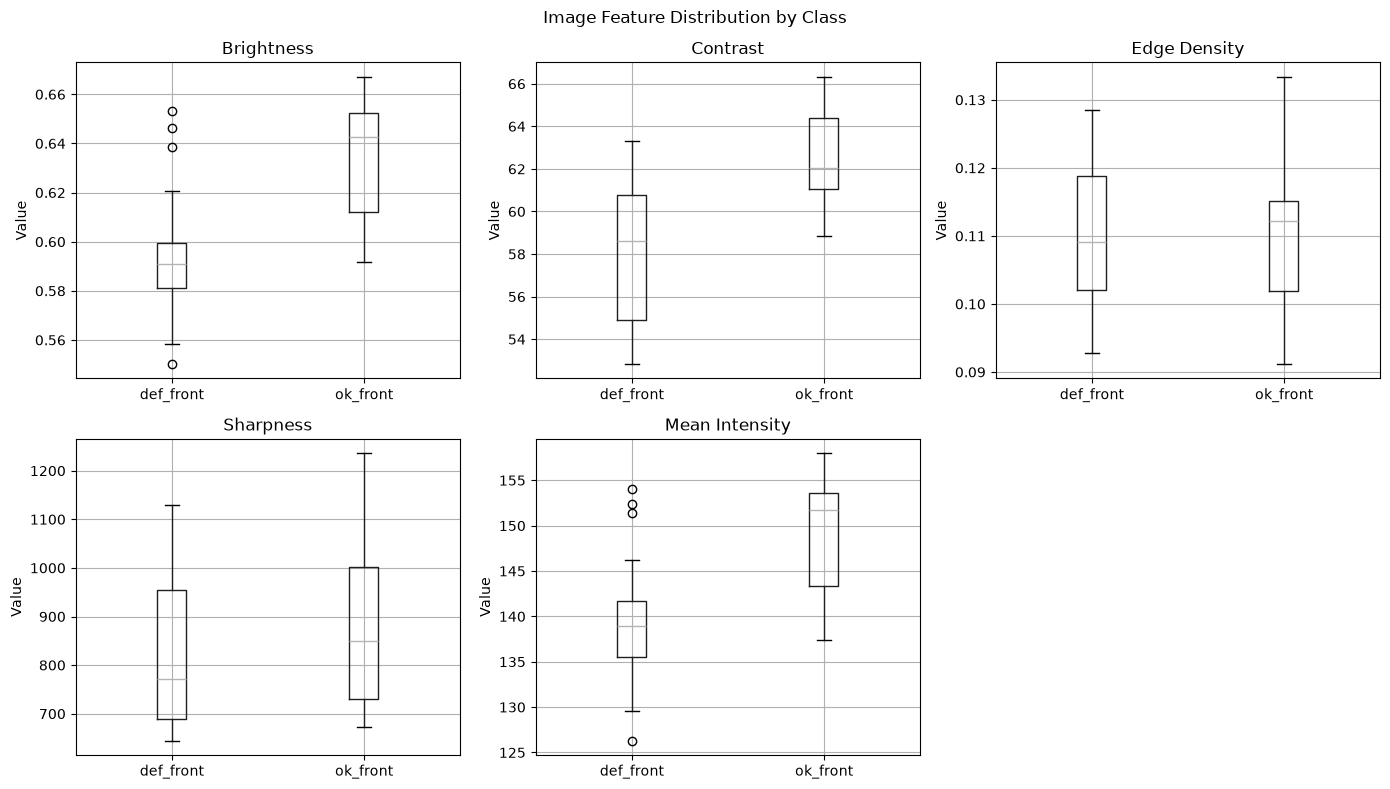

In [34]:
#Create boxplots for each feature in the dataset, grouped by class, to visualize the distribution of feature values across different classes.
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

axes = axes.flatten()

for index, feature_name in enumerate(config.DRIFT_FEATURES):
    eda_features.boxplot(
        column=feature_name,
        by="class_name",
        ax=axes[index],
    )

    axes[index].set_title(
        feature_name.replace("_", " ").title()
    )
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Value")

for index in range(len(config.DRIFT_FEATURES), len(axes)):
    axes[index].axis("off")

plt.suptitle("Image Feature Distribution by Class")
plt.tight_layout()
plt.show()

### 1.4.1 Image-characteristic EDA interpretation

The exploratory data analysis was performed on the leakage-safe training
partition from dataset version `v1`. The final test partition was not used for
EDA, preserving it for independent model evaluation. The training partition
contains 68 images, with 34 acceptable castings and 34 defective castings.

#### Visual observations

The sample images are grayscale top-view images of circular impeller castings.
The castings are generally centred, shown at a similar scale and photographed
against a broadly consistent background.

The acceptable samples have relatively smooth and regular outer boundaries.
Several defective samples show visible surface or edge irregularities,
including small marks and rough or protruding material around the outer
circumference. However, not every defect is equally obvious. Some defective
images appear visually similar to acceptable images when viewed at full-image
scale, suggesting that the model must learn local surface and boundary details
rather than relying only on the overall casting shape.

There is also some variation in illumination between images. This is important
because the model could otherwise learn brightness or background differences
as shortcuts instead of learning genuine defect characteristics.

#### Image-feature statistics

Five interpretable image features were calculated for every training image:
brightness, contrast, edge density, sharpness and mean intensity.

| Feature | Acceptable mean | Defective mean | Defective minus acceptable |
|---|---:|---:|---:|
| Brightness | 0.6357 | 0.5919 | -0.0438 |
| Contrast | 62.6404 | 57.9464 | -4.6940 |
| Edge density | 0.1093 | 0.1107 | +0.0014 |
| Sharpness | 871.9055 | 827.7554 | -44.1501 |
| Mean intensity | 149.4894 | 139.3333 | -10.1561 |

Acceptable images were, on average, brighter than defective images. Their mean
intensity was approximately 10.16 grayscale units higher, while their
normalised brightness was approximately 0.044 higher. Acceptable images also
had higher average contrast and sharpness.

Edge density was almost identical between the classes. Defective images had an
average edge density of 0.1107 compared with 0.1093 for acceptable images.
This small difference indicates that the total amount of edge information
alone is unlikely to separate the classes reliably.

The box plots show the clearest class-level differences in brightness, mean
intensity and contrast. However, the distributions still overlap, particularly
for sharpness and edge density. A few defective images also appear as
brightness and mean-intensity outliers.

The standard deviations for brightness, edge density, sharpness and mean
intensity were similar across the two classes. Contrast varied more among the
defective images, with a standard deviation of 3.2451 compared with 2.0884 for
acceptable images.

These results show that simple global image statistics contain some class-level
differences, but no single feature provides complete separation. The ResNet18
model is therefore required to learn local texture, surface and boundary
patterns. Brightness, contrast, edge density, sharpness and mean intensity will
also be retained as interpretable baseline features for later production-drift
monitoring.

Because the dataset is small, these differences should be treated as
descriptive findings rather than general conclusions about all casting images.

## **Stage 2.1 — Preprocessing & Augmentation** <font color="red">[6 marks]</font>

- **2.1.1 — Convert greyscale image to 3-channel RGB, resize 224, ImageNet normalise [3]**
- **2.1.2 — Train-only augmentation (val/test none) [3]**

**Objective:** Build transforms that match the pretrained ResNet18 backbone.

**Implement in:** src/data_prep.get_transforms

**Inputs → Outputs:** a PIL image → a (3,224,224) normalised tensor; train transform adds augmentation

**TODO:** Convert greyscale image to 3-channel RGB, Resize 224, ImageNet normalise (2.1.1); train-time augmentation (flip/rotation/translate/colour jitter) with val/test NO augmentation (2.1.2).

**Document here:** a before/after visualisation of the transforms.

In [ ]:
# TODO 2.1.1-2.1.2: tf=data_prep.get_transforms(train=True); verify a sample tensor is (3,224,224)
import random

import numpy as np
import torch

#For reproducibility, set the random seed for Python's random module, NumPy, and PyTorch to the value specified in the configuration.
random.seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)
torch.manual_seed(config.RANDOM_SEED)

print("Random seed:", config.RANDOM_SEED)

Random seed: 42


In [ ]:
#Get the data transformations for training and evaluation using the get_transforms function from the data_prep module. 
#The training transformations are obtained by passing train=True, while the evaluation transformations are obtained by passing train=False.
train_transform = data_prep.get_transforms(train=True)
eval_transform = data_prep.get_transforms(train=False)

print("Training transform:")
print(train_transform)

print("\nEvaluation transform:")
print(eval_transform)

Training transform:
Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[-15.0, 15.0], translate=(0.05, 0.05))
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transform:
Compose(
    Grayscale(num_output_channels=3)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
from PIL import Image

#Verify that the evaluation transformation produces a tensor of the expected shape and data type when applied to a sample image 
# from the training split.
sample_path, sample_label = eda_items[0]

with Image.open(sample_path) as image:
    grayscale_image = image.convert("L")

    eval_tensor = eval_transform(grayscale_image)

print("Source image size:", grayscale_image.size)
print("Source image mode:", grayscale_image.mode)
print("Output tensor shape:", tuple(eval_tensor.shape))
print("Output tensor dtype:", eval_tensor.dtype)

Source image size: (300, 300)
Source image mode: L
Output tensor shape: (3, 224, 224)
Output tensor dtype: torch.float32


In [ ]:
#Verify that the source image is in grayscale mode, the output tensor has the expected shape of (3, IMG_SIZE, IMG_SIZE), 
# and the output tensor has a data type of torch.float32.
assert grayscale_image.mode == "L"

assert tuple(eval_tensor.shape) == (
    3,
    config.IMG_SIZE,
    config.IMG_SIZE,
)

assert eval_tensor.dtype == torch.float32

print("PASS: preprocessing output matches ResNet18 requirements.")

PASS: preprocessing output matches ResNet18 requirements.


In [48]:
from torchvision import transforms

#Verify that the three channels of the output tensor are identical when a grayscale image is processed through the evaluation transformation.

#Define a transformation pipeline that converts a grayscale image to a 3-channel tensor, resizes it to the specified image size, 
# and converts it to a tensor without applying normalization or other transformations.
channel_check_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(
            (config.IMG_SIZE, config.IMG_SIZE)
        ),
        transforms.ToTensor(),
    ]
)

with Image.open(sample_path) as image:
    channel_check = channel_check_transform(
        image.convert("L")
    )

channels_equal = (
    torch.equal(channel_check[0], channel_check[1])
    and torch.equal(channel_check[1], channel_check[2])
)

print("Tensor shape:", tuple(channel_check.shape))
print("Three grayscale channels are identical:", channels_equal)

assert channels_equal

Tensor shape: (3, 224, 224)
Three grayscale channels are identical: True


In [ ]:
#Verify that the evaluation transformation produces consistent outputs when applied multiple times to the same grayscale image.
with Image.open(sample_path) as image:
    grayscale_image = image.convert("L")

    eval_output_1 = eval_transform(grayscale_image)
    eval_output_2 = eval_transform(grayscale_image)

print(
    "Evaluation outputs are identical:",
    torch.equal(eval_output_1, eval_output_2),
)

assert torch.equal(eval_output_1, eval_output_2)

Evaluation outputs are identical: True


In [ ]:
#Verify that the training transformation produces consistent outputs when applied multiple times to the same grayscale image,
# when the random seed is fixed before each transformation.
with Image.open(sample_path) as image:
    grayscale_image = image.convert("L")

    torch.manual_seed(config.RANDOM_SEED)
    augmented_output_1 = train_transform(grayscale_image)

    torch.manual_seed(config.RANDOM_SEED)
    augmented_output_2 = train_transform(grayscale_image)

print(
    "Fixed-seed training outputs are identical:",
    torch.equal(augmented_output_1, augmented_output_2),
)

assert torch.equal(
    augmented_output_1,
    augmented_output_2,
)

Fixed-seed training outputs are identical: True


In [ ]:
#Function to convert a tensor to an image for visualization.
def tensor_to_image(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(
        config.IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        config.IMAGENET_STD
    ).view(3, 1, 1)

    image = tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()

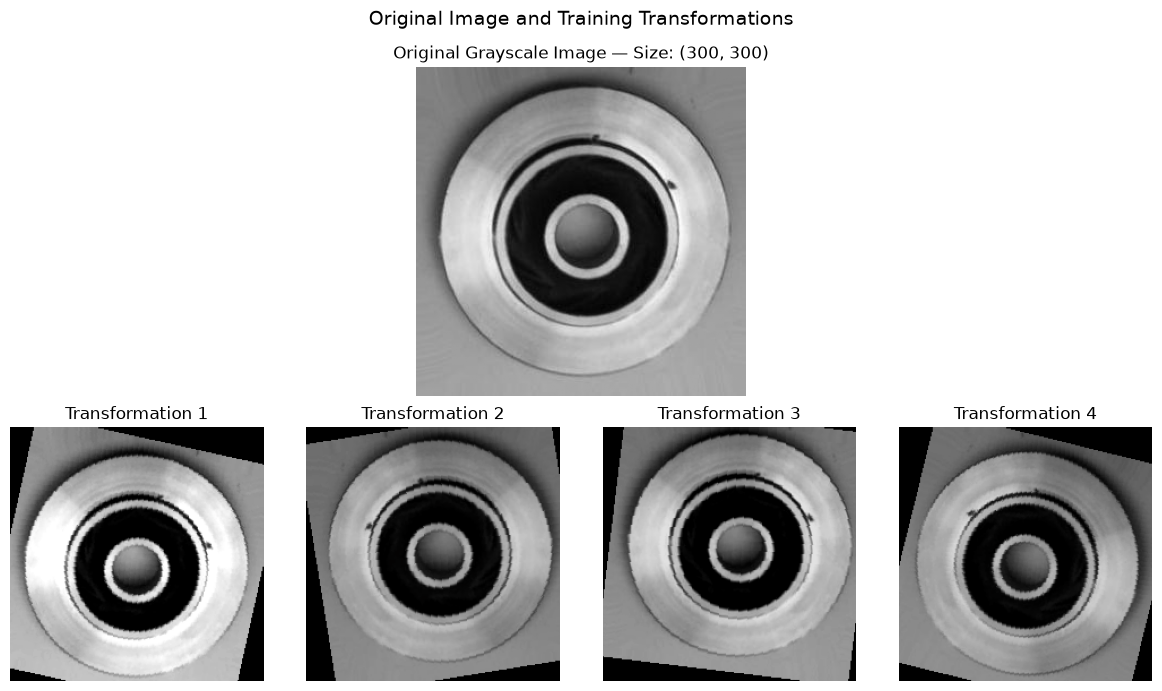

In [ ]:
#Visualize the original grayscale image and the processed tensor after applying the training transformation,
with Image.open(sample_path) as image:
    grayscale_image = image.convert("L")

fig = plt.figure(figsize=(12, 7))

# Create a 2-row × 4-column layout
grid = fig.add_gridspec(
    nrows=2,
    ncols=4,
    height_ratios=[1.3, 1],
)

# First row: original grayscale image spanning all four columns
original_axis = fig.add_subplot(grid[0, :])

original_axis.imshow(
    grayscale_image,
    cmap="gray",
)

original_axis.set_title(
    f"Original Grayscale Image — Size: {grayscale_image.size}"
)
original_axis.axis("off")

# Second row: four transformed images
for index in range(4):
    axis = fig.add_subplot(grid[1, index])

    # Produce different but repeatable augmentations
    torch.manual_seed(
        config.RANDOM_SEED + index
    )

    transformed_tensor = train_transform(
        grayscale_image
    )

    axis.imshow(
        tensor_to_image(transformed_tensor)
    )

    axis.set_title(
        f"Transformation {index + 1}"
    )
    axis.axis("off")

fig.suptitle(
    "Original Image and Training Transformations",
    fontsize=14,
)

plt.tight_layout()
plt.show()

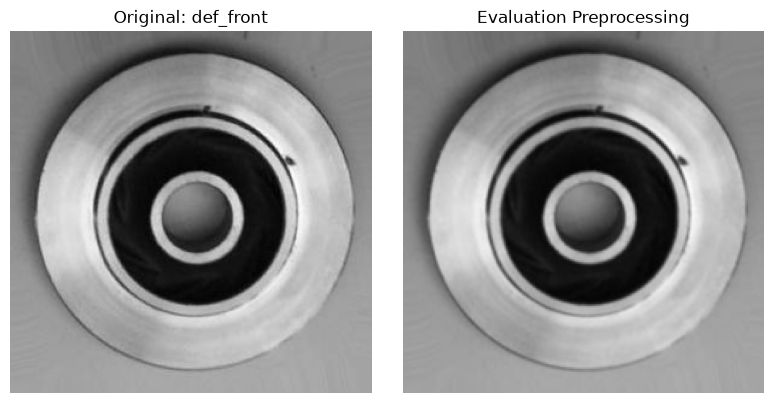

In [ ]:
#Visualize the original grayscale image and the processed tensor after applying the evaluation transformation, 
#displaying them side by side in a matplotlib figure.
with Image.open(sample_path) as image:
    original_image = image.convert("L")
    processed_tensor = eval_transform(original_image)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4),
)

axes[0].imshow(
    original_image,
    cmap="gray",
)
axes[0].set_title(
    f"Original: {config.IDX_TO_CLASS[sample_label]}"
)
axes[0].axis("off")

axes[1].imshow(
    tensor_to_image(processed_tensor)
)
axes[1].set_title("Evaluation Preprocessing")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Display a summary of the preprocessing operations applied to the images in the dataset, indicating whether 
#each operation is applied during training and/or validation/test/inference.
preprocessing_summary = pd.DataFrame(
    [
        {
            "operation": "Grayscale replication to 3 channels",
            "training": "Yes",
            "validation_test_inference": "Yes",
        },
        {
            "operation": "Resize to 224 × 224",
            "training": "Yes",
            "validation_test_inference": "Yes",
        },
        {
            "operation": "Horizontal flip",
            "training": "Random",
            "validation_test_inference": "No",
        },
        {
            "operation": "Rotation and translation",
            "training": "Random",
            "validation_test_inference": "No",
        },
        {
            "operation": "Brightness and contrast jitter",
            "training": "Random",
            "validation_test_inference": "No",
        },
        {
            "operation": "ImageNet normalisation",
            "training": "Yes",
            "validation_test_inference": "Yes",
        },
    ]
)

display(preprocessing_summary)

,operation,training,validation_test_inference
0,Grayscale replication to 3 channels,Yes,Yes
1,Resize to 224 × 224,Yes,Yes
2,Horizontal flip,Random,No
3,Rotation and translation,Random,No
4,Brightness and contrast jitter,Random,No
5,ImageNet normalisation,Yes,Yes


### 2.1 Preprocessing and augmentation interpretation

The source casting images are grayscale and have dimensions of 300 × 300
pixels. The ImageNet-pretrained ResNet18 model expects a three-channel
224 × 224 input, so each image is first converted consistently to grayscale
and then replicated across three channels.

The images are resized to 224 × 224 pixels, converted to floating-point
PyTorch tensors and normalised using the ImageNet channel means and standard
deviations. The resulting tensor shape is `3 × 224 × 224`, which matches the
ResNet18 input requirement.

Controlled augmentation is applied only to the training partition. It includes
horizontal flipping, small rotations and translations, and modest brightness
and contrast changes. These transformations represent plausible variation in
camera positioning and factory lighting while preserving the underlying
casting class.

Validation, test and inference images do not receive random augmentation.
They use only deterministic grayscale replication, resizing, tensor conversion
and ImageNet normalisation. This ensures that evaluation results are stable
and that the same preprocessing contract can later be reused by the FastAPI
inference service.

Random seed 42 is used throughout the project. Reapplying the training
transformation after resetting the same seed produced the same output, while
the evaluation transformation produced identical outputs without resetting
the seed. This confirms that the pipeline supports reproducible experiments.

---
**Outputs feed Stage 2.2+** in `Model_Development_and_Tracking.ipynb` (the versioned splits + transforms are reused to train the model).